In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
def df_nominal_rand():
    nomes = np.array(['Cepa A','Cepa B','Cepa C','Cepa D','Total'])
    freqAbsSimpl = np.random.randint(100,1000,4)
    freqAbsSimpl = np.append(freqAbsSimpl, sum(freqAbsSimpl))
    freqRelSimpl = np.array([round(i/freqAbsSimpl[-1], 2) for i in freqAbsSimpl])
    columns = ['Freq Absol Simpl', 'Freq Relat Simpl']
    df_nominal = pd.DataFrame(columns=columns, index=nomes)
    df_nominal[df_nominal.columns[0]] = freqAbsSimpl
    df_nominal[df_nominal.columns[1]] = freqRelSimpl
    return df_nominal

In [25]:
df_nominal = df_nominal_rand()
df_nominal

,Freq Absol Simpl,Freq Relat Simpl
Cepa A,403,0.19
Cepa B,527,0.24
Cepa C,749,0.34
Cepa D,497,0.23
Total,2176,1.00


In [26]:
def df_ordinal_rand():
    nomes = np.array(['Concent A','Concent B','Concent C','Concent D','Total'])
    freqAbsSimpl = np.random.randint(100,1000,4)
    freqAbsSimpl = np.append(freqAbsSimpl, sum(freqAbsSimpl))
    freqRelSimpl = np.array([round(i/freqAbsSimpl[-1], 2) for i in freqAbsSimpl])
    freqAbsAcum = []
    conta = 0
    for i in freqAbsSimpl[:-1]:
        conta += i
        freqAbsAcum.append(conta)
    freqAbsAcum.append(np.nan)
    freqRelAcum = np.array([round(i/freqAbsAcum[-2], 2) for i in freqAbsAcum])
    columns=['Freq Absol Simp','Freq Relat Simp','Freq Absol Acum','Freq Relat Acum']
    df_ordinal = pd.DataFrame(columns=columns, index=nomes)
    df_ordinal[df_ordinal.columns[0]] = freqAbsSimpl
    df_ordinal[df_ordinal.columns[1]] = freqRelSimpl
    df_ordinal[df_ordinal.columns[2]] = freqAbsAcum
    df_ordinal[df_ordinal.columns[3]] = freqRelAcum
    return df_ordinal

In [28]:
df_ordinal = df_ordinal_rand()
df_ordinal

,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum
Concent A,483,0.27,483.0,0.27
Concent B,555,0.31,1038.0,0.58
Concent C,444,0.25,1482.0,0.83
Concent D,311,0.17,1793.0,1.00
Total,1793,1.00,NaN,NaN


<AxesSubplot:ylabel='Freq Absol Simpl'>

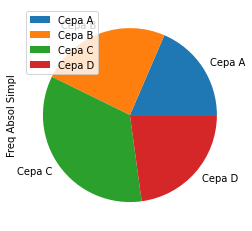

In [34]:
columns = df_ordinal.columns
df_nominal.iloc[:-1].plot(
    kind='pie',
    y=df_nominal.columns[0],
)

<BarContainer object of 1 artists>

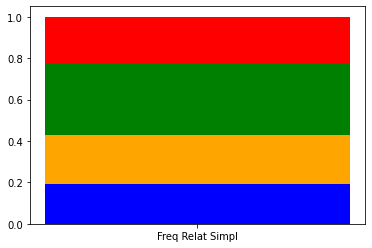

In [43]:
a, b, c, d, e = df_nominal[df_nominal.columns[1]].values
plt.bar(df_nominal.columns[1], a, color='b')
plt.bar(df_nominal.columns[1], b, color='orange', bottom=a)
plt.bar(df_nominal.columns[1], c, color='g', bottom=a+b)
plt.bar(df_nominal.columns[1], d, color='r', bottom=a+b+c)

In [44]:
df_ordinal_I = df_ordinal_rand()
df_ordinal_I

,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum
Concent A,867,0.30,867.0,0.30
Concent B,659,0.22,1526.0,0.52
Concent C,988,0.34,2514.0,0.86
Concent D,421,0.14,2935.0,1.00
Total,2935,1.00,NaN,NaN


Text(0, 0.5, 'Número de ocorrências')

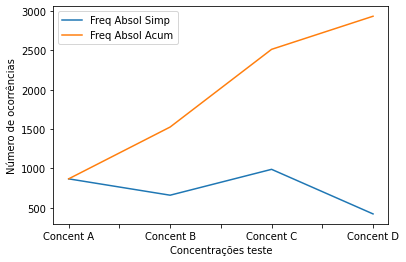

In [47]:
df_ordinal_I[:-1][[columns[0],columns[2]]].plot()
plt.xlabel("Concentrações teste")
plt.ylabel("Número de ocorrências")


Text(0, 0.5, 'Frequencia de ocorrências')

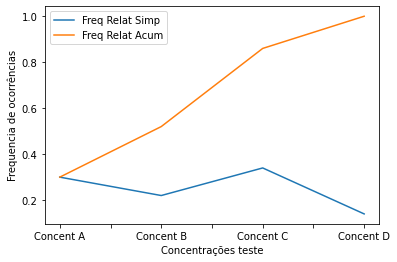

In [48]:

df_ordinal_I[:-1][[columns[1],columns[3]]].plot()
plt.xlabel("Concentrações teste")
plt.ylabel("Frequencia de ocorrências")


Text(0.5, 6.79999999999999, 'Concentrações teste')

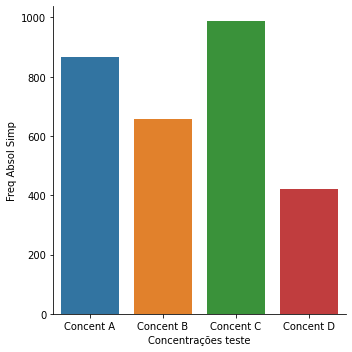

In [49]:
sns.catplot(
    kind='bar',
    x=list(df_ordinal_I[columns[0]].index)[:-1],
    y=columns[0],
    data=df_ordinal_I.iloc[:-1],
)
plt.xlabel("Concentrações teste")

In [53]:
df_ordinal_II = df_ordinal_rand()
df_ordinal_II

,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum
Concent A,700,0.44,700.0,0.44
Concent B,221,0.14,921.0,0.58
Concent C,472,0.30,1393.0,0.87
Concent D,200,0.13,1593.0,1.00
Total,1593,1.00,NaN,NaN


In [57]:
df_ordinal_I['Replica'] = 'Replica A'
df_ordinal_II['Replica'] = 'Replica B'
df_ordinal_replica_I = pd.concat([df_ordinal_I,df_ordinal_II], axis=0).reset_index()
df_ordinal_replica_I.rename(columns={'index': 'Concentração'}, inplace=True)
df_ordinal_replica_I

,Concentração,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum,Replica
0,Concent A,867,0.30,867.0,0.30,Replica A
1,Concent B,659,0.22,1526.0,0.52,Replica A
2,Concent C,988,0.34,2514.0,0.86,Replica A
3,Concent D,421,0.14,2935.0,1.00,Replica A
4,Total,2935,1.00,NaN,NaN,Replica A
5,Concent A,700,0.44,700.0,0.44,Replica B
6,Concent B,221,0.14,921.0,0.58,Replica B
7,Concent C,472,0.30,1393.0,0.87,Replica B
8,Concent D,200,0.13,1593.0,1.00,Replica B
9,Total,1593,1.00,NaN,NaN,Replica B


Text(0.5, 20.80000000000002, 'Concentrações testes')

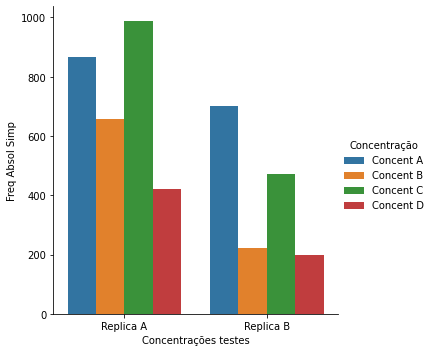

In [59]:
sns.catplot(
    kind='bar',
    x=df_ordinal_replica_I.columns[-1],
    y=columns[0],
    hue=df_ordinal_replica_I.columns[0],
    data=df_ordinal_replica_I.dropna()
)
plt.xlabel('Concentrações testes')


In [60]:
df_ordinal_III = df_ordinal_rand()
df_ordinal_IV = df_ordinal_rand()
df_ordinal_III['Replica'] = 'Replica A'
df_ordinal_IV['Replica'] = 'Replica B'
df_ordinal_replica_II = pd.concat([df_ordinal_III,df_ordinal_IV], axis=0).reset_index()
df_ordinal_replica_II.rename(columns={'index': 'Concentração'}, inplace=True)
df_ordinal_replica_II

,Concentração,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum,Replica
0,Concent A,904,0.30,904.0,0.30,Replica A
1,Concent B,677,0.23,1581.0,0.53,Replica A
2,Concent C,763,0.26,2344.0,0.79,Replica A
3,Concent D,621,0.21,2965.0,1.00,Replica A
4,Total,2965,1.00,NaN,NaN,Replica A
5,Concent A,843,0.44,843.0,0.44,Replica B
6,Concent B,464,0.24,1307.0,0.69,Replica B
7,Concent C,157,0.08,1464.0,0.77,Replica B
8,Concent D,441,0.23,1905.0,1.00,Replica B
9,Total,1905,1.00,NaN,NaN,Replica B


In [62]:
df_ordinal_replica_I['Teste'] = 'Teste 1'
df_ordinal_replica_II['Teste'] = 'Teste 2'
df_ordinal_replica = pd.concat([df_ordinal_replica_I,df_ordinal_replica_II], axis=0).reset_index()
del(df_ordinal_replica['index'])
df_ordinal_replica


,Concentração,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum,Replica,Teste
0,Concent A,867,0.30,867.0,0.30,Replica A,Teste 1
1,Concent B,659,0.22,1526.0,0.52,Replica A,Teste 1
2,Concent C,988,0.34,2514.0,0.86,Replica A,Teste 1
3,Concent D,421,0.14,2935.0,1.00,Replica A,Teste 1
4,Total,2935,1.00,NaN,NaN,Replica A,Teste 1
5,Concent A,700,0.44,700.0,0.44,Replica B,Teste 1
6,Concent B,221,0.14,921.0,0.58,Replica B,Teste 1
7,Concent C,472,0.30,1393.0,0.87,Replica B,Teste 1
8,Concent D,200,0.13,1593.0,1.00,Replica B,Teste 1
9,Total,1593,1.00,NaN,NaN,Replica B,Teste 1


In [65]:
df_ordinal_replica.columns[0]

'Concentração'

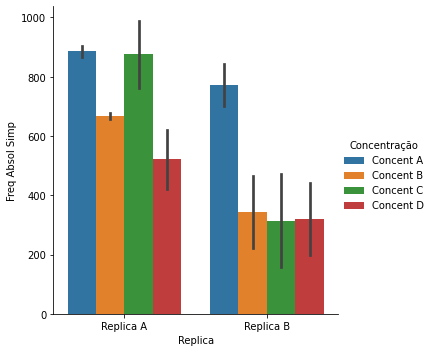

In [66]:
sns.catplot(
    kind='bar',
    x=df_ordinal_replica.columns[-2],
    y=df_ordinal_replica.columns[1],
    hue=df_ordinal_replica.columns[0],
    data=df_ordinal_replica.dropna()
)